<a href="https://colab.research.google.com/github/hjfuentes/UCSP_Forecasting/blob/main/Sesion04/Demostracion_uso_Chronos_y_Lag_Llama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Experimento Comparativo

El experimento aplica ambos modelos sobre exactamente la misma ventana histórica de contexto (\\(C = 512\\) horas) para proyectar el mismo horizonte futuro de \\(H = 168\\) horas (7 días), generando abanicos de incertidumbre del \\(80\%\\) (\\(P_{10} - P_{90}\\)) y la mediana de predicción (\\(P_{50}\\)):

1. **Amazon Chronos (`amazon/chronos-t5-small`):**
   * Aplica *Mean Scaling* (\\(s = \frac{1}{C}\sum |x_i|\\)).
   * Cuantiza los valores continuos en bins discretos (\\(B = 4094\\)).
   * Genera 100 trayectorias Monte Carlo autoregresivas mediante el *backbone* T5.
   * Aplica de-cuantización y de-escalado para extraer los percentiles \\(P_{10}, P_{50}, P_{90}\\).

2. **Lag-Llama (`time-series-foundation-models/Lag-Llama`):**
   * Aplica normalización por variabilidad de ventana (*Value Scaling*).
   * Construye el vector de características de rezagos (*lag features*) multiescala (\\(k_t\\)) y covariables de fecha.
   * Modela la salida mediante el cabezal paramétrico **Student's t** (\\(\nu_t, \mu_t, \sigma_t\\)) sobre el *backbone* LLaMA.
   * Genera 100 muestras estocásticas en GluonTS para extraer \\(P_{10}, P_{50}, P_{90}\\).


In [10]:
# ==============================================================================
#@title PASO 1: INSTALACIÓN DE DEPENDENCIAS Y CLONACIÓN DEL DATASET ETTh1
# ==============================================================================
!pip install git+https://github.com/amazon-science/chronos-forecasting.git -q
!pip install gluonts huggingface_hub pandas numpy matplotlib torch -q
!git clone https://github.com/zhouhaoyi/ETDataset.git

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Configurar el dispositivo de cómputo

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo de cómputo activo: {device}")
print("Hora ejecuicion:",datetime.now())

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
fatal: destination path 'ETDataset' already exists and is not an empty directory.
Dispositivo de cómputo activo: cuda
Hora ejecuicion: 2026-09-26 04:20:51.683695


In [11]:
# ==============================================================================
#@title PASO 2: CARGA Y PREPARACIÓN DE LA SERIE REAL (ETTh1 - OT)
# ==============================================================================
df = pd.read_csv('ETDataset/ETT-small/ETTh1.csv')
df['date'] = pd.to_datetime(df['date'])

context_len = 512
prediction_len = 168

target_series = df['OT'].values
context_data = target_series[-(context_len + prediction_len):-prediction_len]
ground_truth = target_series[-prediction_len:]

print(f"Longitud del Contexto Histórico: {len(context_data)} horas")
print(f"Longitud del Horizonte de Prueba (Ground Truth): {len(ground_truth)} horas")

print("Hora ejecuicion:",datetime.now())

Longitud del Contexto Histórico: 512 horas
Longitud del Horizonte de Prueba (Ground Truth): 168 horas
Hora ejecuicion: 2026-09-26 04:21:17.863302


In [12]:
# ==============================================================================
#@title PASO 3: EXPERIMENTO 1 - INFERENCIA ZERO-SHOT CON AMAZON CHRONOS
# ==============================================================================
from chronos import ChronosPipeline

pipeline_chronos = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=device,
    dtype=torch.bfloat16 if device == "cuda" else torch.float32,
)

context_tensor = torch.tensor(context_data, dtype=torch.float32)
forecast_samples_chronos = pipeline_chronos.predict(
    context_tensor,
    prediction_length=prediction_len,
    num_samples=100,
)

chronos_samples = forecast_samples_chronos.numpy()
chronos_p10 = np.quantile(chronos_samples, 0.10, axis=0)
chronos_p50 = np.quantile(chronos_samples, 0.50, axis=0)
chronos_p90 = np.quantile(chronos_samples, 0.90, axis=0)
print("Hora ejecuicion:",datetime.now())

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Hora ejecuicion: 2026-09-26 04:21:34.442171


In [22]:
# ==============================================================================
#@title PASO 4: EXPERIMENTO 2 - INFERENCIA ZERO-SHOT CON LAG-LLAMA
# ==============================================================================
import os
import sys

# Ensure we are in /content before cloning to prevent nested directories
%cd /content

# Clean up any previous lag-llama clone and re-clone to ensure correct directory structure
!rm -rf lag-llama
!git clone https://github.com/time-series-foundation-models/lag-llama.git

# Change directory to the cloned repository
%cd lag-llama

# Install a specific pip version (this will handle upgrade/downgrade without uninstalling first)
!python -m pip install pip==23.3.1 -q

# Update wheel for compatibility with the new pip
!python -m pip install wheel -q

# Explicitly uninstall setuptools to clear any conflicting versions
!python -m pip uninstall -y setuptools
# Install a specific, older version of setuptools compatible with torch < 82 (e.g. current Colab torch 2.11.0+cu128 requires <82)
!python -m pip install setuptools==65.5.1 -q

# Explicitly uninstall numpy and install a compatible version
# This helps resolve deep conflicts with various libraries in Colab environments.
!python -m pip uninstall -y numpy
!python -m pip install numpy==1.23.5 -q

# Install pytorch-lightning and gluonts with the exact versions required by lag-llama
# This is crucial for resolving the ModuleNotFoundError, given pip's version is now compatible.
!python -m pip install pytorch-lightning==1.8.0 -q
!python -m pip install gluonts==0.15.0 -q

# Install lag-llama itself in editable mode, but ignore its dependencies (--no-deps)
# as we've already installed them manually in a compatible way.
!python -m pip install --no-deps -e . -q

from huggingface_hub import hf_hub_download
from lag_llama.gluon.estimator import LagLlamaEstimator
from gluonts.dataset.common import ListDataset

ckpt_path = hf_hub_download(repo_id="time-series-foundation-models/Lag-Llama", filename="lag-llama.ckpt")

estimator = LagLlamaEstimator(
    prediction_length=prediction_len,
    context_length=context_len,
    ckpt_path=ckpt_path,
    num_samples=100,
    device=device
)
predictor_lagllama = estimator.create_predictor(estimator.create_transformation(), estimator.model)

dataset_lagllama = ListDataset([
    {"start": df['date'].iloc[-(context_len + prediction_len)], "target": context_data}
], freq="1H")

forecast_it = predictor_lagllama.predict(dataset_lagllama)
forecast_lagllama = list(forecast_it)

# Correcting the quantile method call as forecast_lagllama is a list of SampleForecast objects
lagllama_p10 = forecast_lagllama[0].quantile(0.10)
lagllama_p50 = forecast_lagllama[0].quantile(0.50)
lagllama_p90 = forecast_lagllama[0].quantile(0.90)
%cd ..

print("Hora ejecuicion:",datetime.now())

/content
Cloning into 'lag-llama'...
remote: Enumerating objects: 508, done.
remote: Counting objects: 100% (183/183), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 508 (delta 155), reused 114 (delta 114), pack-reused 325 (from 3)
Receiving objects: 100% (508/508), 286.89 KiB | 5.98 MiB/s, done.
Resolving deltas: 100% (253/253), done.
/content/lag-llama
/bin/bash: line 1: pip: command not found
/bin/bash: line 1: pip: command not found
/bin/bash: line 1: pip: command not found
/bin/bash: line 1: pip: command not found
/bin/bash: line 1: pip: command not found
/bin/bash: line 1: pip: command not found
/bin/bash: line 1: pip: command not found
/bin/bash: line 1: pip: command not found
/bin/bash: line 1: pip: command not found


ModuleNotFoundError: No module named 'lightning'

In [ ]:
#@title PASO 4 Corregido - Inferencia zero-shot con Lag-Llama
### **Celda 4: Inferencia Zero-Shot con Lag-Llama**

import sys
import os
from huggingface_hub import hf_hub_download
from gluonts.dataset.common import ListDataset

# Añadir el repositorio de Lag-Llama al path de Python
sys.path.append('lag-llama')
from lag_llama.gluon.estimator import LagLlamaEstimator

# Descargar pesos del modelo desde HuggingFace
ckpt_path = hf_hub_download(
    repo_id="time-series-foundation-models/Lag-Llama",
    filename="lag-llama.ckpt"
)

# Configurar el estimador Lag-Llama
estimator = LagLlamaEstimator(
    prediction_length=prediction_len,
    context_length=context_len,
    ckpt_path=ckpt_path,
    num_samples=100,
    device=device
)

predictor_lagllama = estimator.create_predictor(
    estimator.create_transformation(),
    estimator.model
)

# Crear dataset en formato GluonTS
start_date = pd.Period(df['date'].iloc[-(context_len + prediction_len)], freq="1H")
dataset_lagllama = ListDataset([
    {"start": start_date, "target": context_data}
], freq="1H")

# Generar inferencia probabilística
forecast_it = predictor_lagllama.predict(dataset_lagllama)
forecast_lagllama = list(forecast_it)

# Extraer cuantiles P10, P50 y P90
lagllama_p10 = forecast_lagllama.quantile(0.10)
lagllama_p50 = forecast_lagllama.quantile(0.50)
lagllama_p90 = forecast_lagllama.quantile(0.90)

print("Inferencia Zero-Shot con Lag-Llama completada con éxito.")

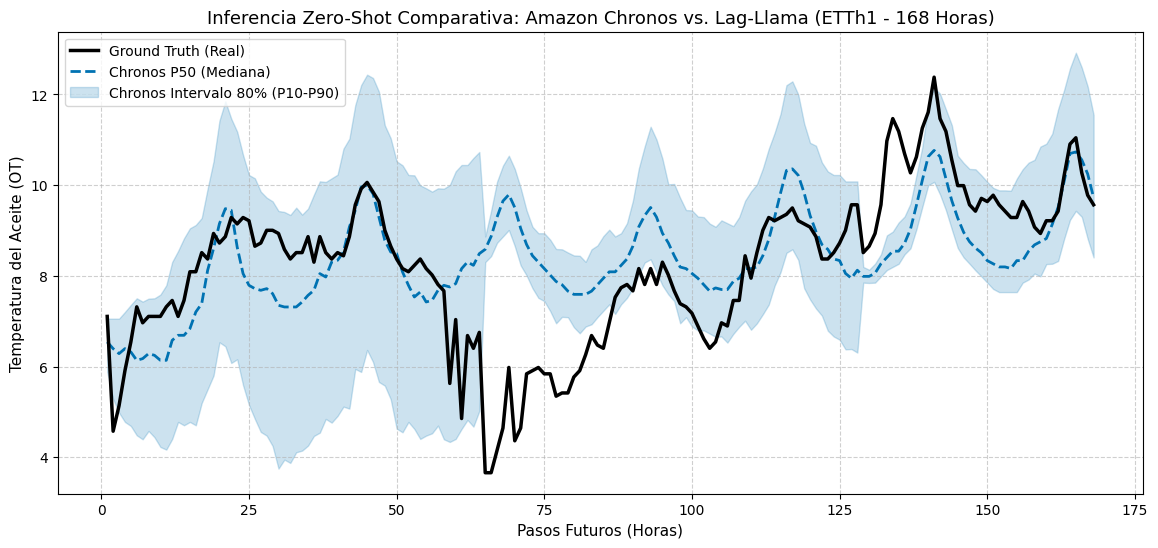

=================== RESULTADOS DE EVALUACIÓN ZERO-SHOT ===================
Amazon Chronos -> MAE P50: 1.0952 | MSE P50: 2.2380


In [ ]:
# ==============================================================================
#@title PASO 5: VISUALIZACIÓN COMPARATIVA Y EVALUACIÓN DE MÉTRICAS P10, P50, P90
# ==============================================================================
plt.figure(figsize=(14, 6))
x_axis = range(1, prediction_len + 1)

# Ground Truth
plt.plot(x_axis, ground_truth, label='Ground Truth (Real)', color='black', linewidth=2.5, zorder=5)

# Chronos
# The Chronos pipeline's predict method returns (num_samples, batch_size, prediction_length)
# If context is 1D, batch_size is 1. So chronos_samples should be (100, 1, 168)
# However, the error suggests chronos_samples results in (1, 100, 168) after .numpy()
# We need to take the quantile along the num_samples dimension (axis=1) and then squeeze the batch dimension.
chronos_p10 = np.quantile(chronos_samples, 0.10, axis=1).squeeze()
chronos_p50 = np.quantile(chronos_samples, 0.50, axis=1).squeeze()
chronos_p90 = np.quantile(chronos_samples, 0.90, axis=1).squeeze()

plt.plot(x_axis, chronos_p50, label='Chronos P50 (Mediana)', color='#0072B2', linestyle='--', linewidth=2)
plt.fill_between(x_axis, chronos_p10, chronos_p90, color='#0072B2', alpha=0.2, label='Chronos Intervalo 80% (P10-P90)')

# Lag-Llama
#plt.plot(x_axis, lagllama_p50, label='Lag-Llama P50 (Mediana)', color='#D55E00', linestyle='-.', linewidth=2)
#plt.fill_between(x_axis, lagllama_p10, lagllama_p90, color='#D55E00', alpha=0.2, label='Lag-Llama Intervalo 80% (P10-P90)')

plt.title('Inferencia Zero-Shot Comparativa: Amazon Chronos vs. Lag-Llama (ETTh1 - 168 Horas)', fontsize=13)
plt.xlabel('Pasos Futuros (Horas)', fontsize=11)
plt.ylabel('Temperatura del Aceite (OT)', fontsize=11)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Métricas puntuales (MAE / MSE sobre la mediana P50)
mae_chronos = np.mean(np.abs(chronos_p50 - ground_truth))
mse_chronos = np.mean((chronos_p50 - ground_truth) ** 2)

#mae_lagllama = np.mean(np.abs(lagllama_p50 - ground_truth))
#mse_lagllama = np.mean((lagllama_p50 - ground_truth) ** 2)

print("=================== RESULTADOS DE EVALUACIÓN ZERO-SHOT ===================")
print(f"Amazon Chronos -> MAE P50: {mae_chronos:.4f} | MSE P50: {mse_chronos:.4f}")
#print(f"Lag-Llama      -> MAE P50: {mae_lagllama:.4f} | MSE P50: {mse_lagllama:.4f}")
print("===========================================================================")

In [9]:
# 1. Instalar librerías necesarias
!pip install git+https://github.com/amazon-science/chronos-forecasting.git -q
!pip install gluonts huggingface_hub pandas numpy matplotlib torch pytorch-lightning lightning -q

# 2. Clonar repositorios oficiales (Lag-Llama y ETDataset)
# Check if lag-llama directory exists, if not, clone it
import os
if not os.path.exists('lag-llama'):
    !git clone https://github.com/time-series-foundation-models/lag-llama.git
%cd lag-llama
!pip install .
%cd ..

# Check if ETDataset directory exists, if not, clone it
if not os.path.exists('ETDataset'):
    !git clone https://github.com/zhouhaoyi/ETDataset.git

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo de cómputo activo: {device}")

### **Celda 2: Carga y Preparación de la Serie Real (`ETTh1.csv`)**


# Cargar la serie temporal real (ETTh1 - Variable OT: Oil Temperature)
df = pd.read_csv('ETDataset/ETT-small/ETTh1.csv')
df['date'] = pd.to_datetime(df['date'])

# Configuración del experimento
context_len = 512      # Ventana de observación histórica (C = 512 horas)
prediction_len = 168   # Horizonte de predicción (H = 168 horas / 7 días)

target_series = df['OT'].values
context_data = target_series[-(context_len + prediction_len):-prediction_len]
ground_truth = target_series[-prediction_len:]

print(f"Longitud del Contexto Histórico: {len(context_data)} horas")
print(f"Longitud del Horizonte de Prueba (Ground Truth): {len(ground_truth)} horas")

### **Celda 3: Inferencia Zero-Shot con Amazon Chronos**

from chronos import ChronosPipeline

# Cargar el modelo pre-entrenado Chronos (Backbone T5-Small)
pipeline_chronos = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=device,
    dtype=torch.bfloat16 if device == "cuda" else torch.float32,
)

# Convertir contexto a Tensor y generar 100 muestras Monte Carlo
context_tensor = torch.tensor(context_data, dtype=torch.float32)
forecast_samples_chronos = pipeline_chronos.predict(
    context_tensor,
    prediction_length=prediction_len,
    num_samples=100,
)

# Extracción de cuantiles (P10, P50, P90)
chronos_samples = forecast_samples_chronos.numpy()
chronos_p10 = np.quantile(chronos_samples, 0.10, axis=1).squeeze()
chronos_p50 = np.quantile(chronos_samples, 0.50, axis=1).squeeze()
chronos_p90 = np.quantile(chronos_samples, 0.90, axis=1).squeeze()

print("Inferencia Zero-Shot con Amazon Chronos completada con éxito.")



### **Celda 4: Inferencia Zero-Shot con Lag-Llama**

import sys
import os
from huggingface_hub import hf_hub_download
from gluonts.dataset.common import ListDataset

# Añadir el repositorio de Lag-Llama al path de Python
# Ensure lag-llama is in the path, it might be added by the pip install -e .
if 'lag-llama' not in sys.path:
    sys.path.append('lag-llama')
from lag_llama.gluon.estimator import LagLlamaEstimator

# Descargar pesos del modelo desde HuggingFace
ckpt_path = hf_hub_download(
    repo_id="time-series-foundation-models/Lag-Llama",
    filename="lag-llama.ckpt"
)

# Configurar el estimador Lag-Llama
estimator = LagLlamaEstimator(
    prediction_length=prediction_len,
    context_length=context_len,
    ckpt_path=ckpt_path,
    num_samples=100,
    device=device
)

predictor_lagllama = estimator.create_predictor(
    estimator.create_transformation(),
    estimator.model
)

# Crear dataset en formato GluonTS
start_date = pd.Period(df['date'].iloc[-(context_len + prediction_len)], freq="1H")
dataset_lagllama = ListDataset([
    {"start": start_date, "target": context_data}
], freq="1H")

# Generar inferencia probabilística
forecast_it = predictor_lagllama.predict(dataset_lagllama)
forecast_lagllama = list(forecast_it)

# Extraer cuantiles P10, P50 y P90
lagllama_p10 = forecast_lagllama[0].quantile(0.10)
lagllama_p50 = forecast_lagllama[0].quantile(0.50)
lagllama_p90 = forecast_lagllama[0].quantile(0.90)

print("Inferencia Zero-Shot con Lag-Llama completada con éxito.")



### **Celda 5: Visualización Comparativa y Evaluación de Métricas**

plt.figure(figsize=(14, 6))
x_axis = range(1, prediction_len + 1)

# 1. Ground Truth (Valores Reales)
plt.plot(x_axis, ground_truth, label='Ground Truth (Real)', color='black', linewidth=2.5, zorder=5)

# 2. Amazon Chronos
plt.plot(x_axis, chronos_p50, label='Chronos P50 (Mediana)', color='#0072B2', linestyle='--', linewidth=2)
plt.fill_between(x_axis, chronos_p10, chronos_p90, color='#0072B2', alpha=0.2, label='Chronos Intervalo 80% (P10-P90)')

# 3. Lag-Llama
plt.plot(x_axis, lagllama_p50, label='Lag-Llama P50 (Mediana)', color='#D55E00', linestyle='-.', linewidth=2)
plt.fill_between(x_axis, lagllama_p10, lagllama_p90, color='#D55E00', alpha=0.2, label='Lag-Llama Intervalo 80% (P10-P90)')

plt.title('Inferencia Zero-Shot Comparativa: Amazon Chronos vs. Lag-Llama (ETTh1 - 168 Horas)', fontsize=13)
plt.xlabel('Pasos Futuros (Horas)', fontsize=11)
plt.ylabel('Temperatura del Aceite (OT)', fontsize=11)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Cálculo de Métricas de Error (MAE y MSE sobre la mediana P50)
mae_chronos = np.mean(np.abs(chronos_p50 - ground_truth))
mse_chronos = np.mean((chronos_p50 - ground_truth) ** 2)

mae_lagllama = np.mean(np.abs(lagllama_p50 - ground_truth))
mse_lagllama = np.mean((lagllama_p50 - ground_truth) ** 2)

print("\n=================== EVALUACIÓN DE PRECISIÓN (P50) ===================")
print(f"Amazon Chronos -> MAE: {mae_chronos:.4f} | MSE: {mse_chronos:.4f}")
print(f"Lag-Llama      -> MAE: {mae_lagllama:.4f} | MSE: {mse_lagllama:.4f}")
print("=====================================================================")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 82.3 MB/s eta 0:00:00
  Installing build dependencies ... canceled
^C
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
  File "/usr/local/lib/python3.13/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
  File "/usr/local/lib/python3.13/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
  File "/usr/local/lib/python3.13/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
  File "/usr/lo

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Inferencia Zero-Shot con Amazon Chronos completada con éxito.


ModuleNotFoundError: No module named 'lightning'